In [1]:
import numpy as np
import pandas as pd
import matplotlib
import scipy
import sklearn
import matplotlib.pyplot as plt
from numpy import mean, std
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from scipy.cluster.vq import kmeans2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from math import sqrt

In [2]:
model_ready_data = pd.read_csv('model_ready_data.csv')
model_ready_data.head(6)

,subject,trial_global,stimulus_idx,choice,reward,modality
0,sub-01,1,0,0,0.0,visuotactile
1,sub-01,2,1,1,0.0,visuotactile
2,sub-01,3,2,0,1.0,visuotactile
3,sub-01,4,3,1,0.0,visuotactile
4,sub-01,5,4,0,1.0,visuotactile
5,sub-01,6,5,0,1.0,visuotactile


In [3]:
# model_ready_data, combined file for all participants preprocessed behavioral data

In [4]:
print(f"Participants in data: {model_ready_data['subject'].nunique()}")

Participants in data: 62


In [5]:
model_ready_data.shape

(21870, 6)

In [6]:
model_ready_data.isna().sum()

subject         0
trial_global    0
stimulus_idx    0
choice          0
reward          0
modality        0
dtype: int64

In [7]:
# Zero missing values

In [8]:
# Building a Beta-Binomial Model
# Four functions drive the model: expected_value predicts reward probability pre-trial, update tracks outcomes via alpha/beta counts, softmax converts these to choice probabilities, and calculate_log_likelihood sums prediction accuracy into one participant score.

In [9]:
def expected_value(alpha, beta):
    return alpha / (alpha + beta)

# Alpha and beta are the two parameters of a Beta distribution.
# expected_value() returns mean expected value alpha/(alpha+beta) as the model's single best prediction of the reward probability.

In [10]:
def update(alpha, beta, reward):
    if reward == 1:
        alpha += 1
    else:
        beta += 1
    return alpha, beta

# Updates belief after outcome, based on what happened.
# Alpha and beta together encode a full probability distribution.

In [11]:
def softmax(value_attract, value_not, temperature):
    exp_attract = np.exp(value_attract * temperature)
    exp_not = np.exp(value_not * temperature)
    p_attract = exp_attract / (exp_attract + exp_not)
    return p_attract

# Multiplying each expected value by temperature, then applying exponential function with np.exp 
# Converting transformed values to choice probabilities

In [12]:
# calculate_log_likelihood() as a function that takes a participant's data and temperature, loops through all 350+ trials one by one, amd uses the previously defined functions.
# Returns how well the model predicted over all 350+ choices

def calculate_log_likelihood(participant_data, temperature):
    alpha_beta = np.ones((9, 2, 2)) # Storage for one participant's entire learning history, the whole array being the Beta distribution
    total_log_lik = 0
    
# looping through Every Trial:
    for _, trial in participant_data.iterrows():
        stimulus = int(trial['stimulus_idx'])
        action = int(trial['choice'])
        reward = trial['reward']

        # Getting current belief before each trial alpha / beta
        alpha = alpha_beta[stimulus][action][0]
        beta = alpha_beta[stimulus][action][1]
        
        # Calculating expected values for both actions
        ev_attract = expected_value(alpha_beta[stimulus][0][0], alpha_beta[stimulus][0][1])
        ev_not = expected_value(alpha_beta[stimulus][1][0], alpha_beta[stimulus][1][1])

        # Predicting choices
        if action == 0:
            p_chosen = softmax(ev_attract, ev_not, temperature)
        else:
            p_attract = softmax(ev_attract, ev_not, temperature)
            p_chosen = 1 - p_attract
        
        total_log_lik += np.log(p_chosen + 1e-10) # Adds the log probability of the chosen action to the running total
        
        # Updating beliefs based on what happened
        new_alpha, new_beta = update(alpha, beta, reward)
        alpha_beta[stimulus][action][0] = new_alpha
        alpha_beta[stimulus][action][1] = new_beta
    
    return total_log_lik

In [13]:
def neg_log_likelihood(temp):
    return -calculate_log_likelihood(participant_data, temp)

# Converts the model's fit into a form the minimize_scalar can minimize
# Since calculate_log_likelihood() returns higher values for better fit,
# but minimize_scalar() can only find minimum values, I take the negative.

In [14]:
# Looping through all 62 subjects
all_subjects = model_ready_data['subject'].unique()
results = []

for idx, participant in enumerate(all_subjects):
    data = model_ready_data[model_ready_data['subject'] == participant].sort_values('trial_global')
    n_trials = len(data)
    
    def neg_ll(temp):
        return -calculate_log_likelihood(data, temp)
    res = minimize_scalar(neg_ll, bounds=(0.01, 20), method='bounded')

    best_temp = res.x
    best_ll = -res.fun # Converts back from neg_ll to actual ll
    avg_ll = best_ll / n_trials
    prob = np.exp(avg_ll)

    results.append({
        'subject': participant,
        'best_temp': best_temp,
        'best_ll': best_ll,
        'n_trials': n_trials,
        'avg_ll': avg_ll,
        'probability': prob
    })
    if idx < 4:
        print(f"Subject: {participant} ({n_trials} trials)")
        print(f"Best temp: {best_temp:.3f}")
        print(f"Log likelihood: {best_ll:.2f}")
        print(f"Avg per trial: {avg_ll:.3f}")
        print(f"Probability: {prob:.3f}")    
        print("---")

results_df = pd.DataFrame(results)

Subject: sub-01 (355 trials)
Best temp: 1.810
Log likelihood: -222.85
Avg per trial: -0.628
Probability: 0.534
---
Subject: sub-02 (358 trials)
Best temp: 2.223
Log likelihood: -222.95
Avg per trial: -0.623
Probability: 0.536
---
Subject: sub-03 (360 trials)
Best temp: 1.400
Log likelihood: -241.12
Avg per trial: -0.670
Probability: 0.512
---
Subject: sub-04 (360 trials)
Best temp: 0.010
Log likelihood: -249.58
Avg per trial: -0.693
Probability: 0.500
---


In [15]:
print(results_df.columns.tolist())

['subject', 'best_temp', 'best_ll', 'n_trials', 'avg_ll', 'probability']


In [16]:
random_ll = -0.693 * 350
better_count = 0

for participant in all_subjects:
    participant_results = results_df[results_df['subject'] == participant]
    best_ll = participant_results['best_ll'].values[0] 
    if best_ll > random_ll:
        better_count += 1

print(f"Participants better than random: {better_count} out of {len(all_subjects)}")

Participants better than random: 41 out of 62


In [17]:
# Calculating prediction probability range across participants
best_idx = results_df['probability'].idxmax()
best_subj = results_df.loc[best_idx, 'subject']
best_prob = results_df.loc[best_idx, 'probability']

worst_idx = results_df['probability'].idxmin()
worst_subj = results_df.loc[worst_idx, 'subject']
worst_prob = results_df.loc[worst_idx, 'probability']

print(f"Best prediction: {best_subj} with {best_prob:.3f}")
print(f"Worst prediction: {worst_subj} with {worst_prob:.3f}")
print(f"Mean: {results_df['probability'].mean():.3f}")
print(f"Median: {results_df['probability'].median():.3f}")

Best prediction: sub-48 with 0.611
Worst prediction: sub-62 with 0.500
Mean: 0.523
Median: 0.514


In [18]:
# On average, the model assigns 52.3% probability to the choice the participant made in reality

In [19]:
# Extracting BIC values
results_df['bic'] = -2 * results_df['best_ll'] + 1 * np.log(results_df['n_trials'])
print(f"BIC range: {results_df['bic'].min():.1f} - {results_df['bic'].max():.1f}")
print(f"Mean BIC: {results_df['bic'].mean():.1f}")
print(f"Median BIC: {results_df['bic'].median():.1f}")

BIC range: 168.1 - 505.0
Mean BIC: 463.2
Median BIC: 478.2


In [20]:
# Temp statistics
print(f"Mean: {results_df['best_temp'].mean():.2f}")
print(f"Range: {results_df['best_temp'].min():.2f} - {results_df['best_temp'].max():.2f}")
print("5 highest temperatures:")
print(results_df.nlargest(5, 'best_temp')[['subject', 'best_temp']])
print("5 lowest temperatures:")
print(results_df.nsmallest(5, 'best_temp')[['subject', 'best_temp']])

Mean: 1.47
Range: 0.01 - 4.95
5 highest temperatures:
   subject  best_temp
45  sub-48   4.946328
55  sub-58   4.017669
33  sub-36   3.789302
23  sub-24   3.455768
43  sub-46   3.238366
5 lowest temperatures:
   subject  best_temp
3   sub-04   0.010007
21  sub-22   0.010007
26  sub-27   0.010007
53  sub-56   0.010007
59  sub-62   0.010007


In [21]:
# Full range exists, with all temperatures between bounds (0.01-20). 
# The model captures real individual differences with both extremes present in behavior (deterministic / exploratory)

In [22]:
# Refitting original study group allocation to Bayesian model:
# Reading in original group labels
groups = pd.read_csv('BestFitting.tsv', sep='\t', header=None,
                     names=['subject_num', 'group', 'their_value'])

# Converting 1 → sub-01, 2 → sub-02..
groups['subject'] = 'sub-' + groups['subject_num'].astype(str).str.zfill(2)

# Merging with best results
highest_ll = results_df.loc[results_df.groupby('subject')['best_ll'].idxmax()].copy() # For each subject, finds row with highest log likelihood
highest_ll = pd.merge(highest_ll, groups[['subject', 'group']], on='subject') # Combining two tables based on a common column

print(highest_ll.head())
# End result is one row per participant with their best fit + group label

  subject  best_temp     best_ll  n_trials    avg_ll  probability         bic  \
0  sub-01   1.810029 -222.849887       355 -0.627746     0.533794  451.571891   
1  sub-02   2.222690 -222.954747       358 -0.622779     0.536452  451.790027   
2  sub-03   1.399894 -241.123047       360 -0.669786     0.511818  488.132198   
3  sub-04   0.010007 -249.581919       360 -0.693283     0.499932  505.049941   
4  sub-05   2.744365 -229.766044       359 -0.640017     0.527284  465.415410   

      group  
0      asym  
1      asym  
2      asym  
3     basic  
4  transfer  


In [23]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    
    "legend.fontsize": 11,

    "grid.alpha": 0.3,
})

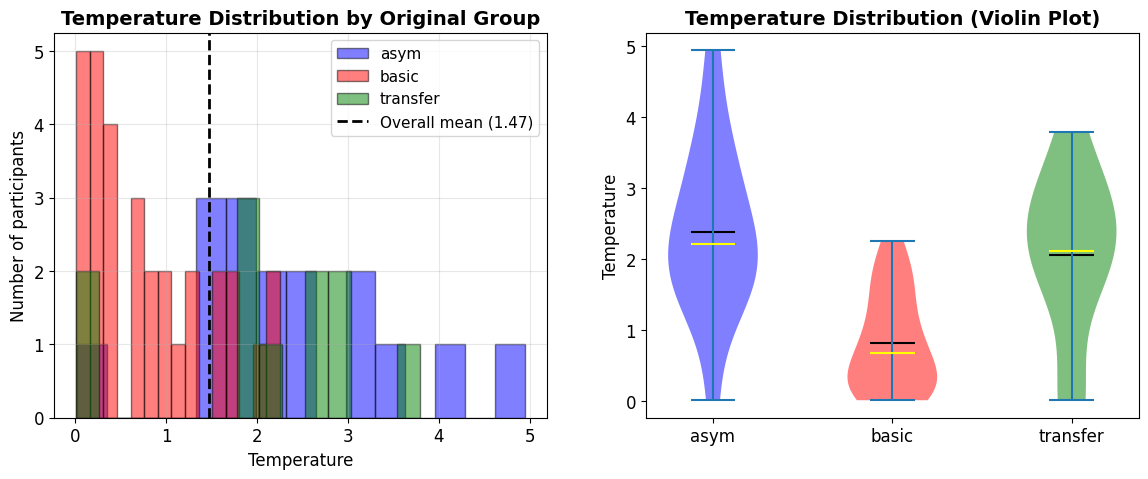

In [24]:
# Plotting temperautre distribution by group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histograms
colors = {'asym': 'blue', 'basic': 'red', 'transfer': 'green'}
for group, color in colors.items():
    group_temps = highest_ll[highest_ll['group'] == group]['best_temp']
    axes[0].hist(group_temps, bins=15, alpha=0.5, label=group, color=color, edgecolor='black')

axes[0].axvline(results_df['best_temp'].mean(), color='black', linestyle='--', linewidth=2, label=f'Overall mean ({results_df["best_temp"].mean():.2f})')
axes[0].set_xlabel('Temperature', fontsize=12)
axes[0].set_ylabel('Number of participants', fontsize=12)
axes[0].set_title('Temperature Distribution by Original Group', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Violin plot
def matplotlib_violin(ax, data, groups, y_col):    
    # Data prepping for each group
    group_data = [data[data['group'] == g][y_col].values for g in groups]
    
    parts = ax.violinplot(group_data, positions=range(len(groups)), 
                          showmeans=True, showmedians=True)
    
    colors = ['blue', 'red', 'green']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.5)
    
    parts['cmeans'].set_color('black')
    parts['cmedians'].set_color('yellow')
    
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels((groups), fontsize=12)
    ax.set_ylabel('Temperature', fontsize=12)
    ax.set_title('Temperature Distribution (Violin Plot)', fontsize=14, fontweight='bold')
    
    return ax

matplotlib_violin(axes[1], highest_ll, ['asym', 'basic', 'transfer'], 'best_temp')
plt.show()

In [25]:
# H1: Do participants classified into different Q-learning groups (Basic/Asym/Transfer) show differential fit in the Bayesian model?

# Extracting total log-likelihood averaged by group
group_means = highest_ll.groupby('group')['best_ll'].mean()
print(group_means)

group
asym       -220.448956
basic      -240.457275
transfer   -220.556372
Name: best_ll, dtype: float64


In [26]:
# Asym and Transfer groups are fit equally well
# Basic group fits much worse (~20 points lower)

In [27]:
# Average log-likelihood per trial by group
group_avg = highest_ll.groupby('group')['avg_ll'].mean()
print(group_avg)

group
asym       -0.618104
basic      -0.674507
transfer   -0.618065
Name: avg_ll, dtype: float64


In [28]:
# Calculating effect sizes (Cohens D)

# Extracting group specific log-likelihood values
asym_ll = highest_ll[highest_ll['group']=='asym']['best_ll']
basic_ll = highest_ll[highest_ll['group']=='basic']['best_ll']
transfer_ll = highest_ll[highest_ll['group']=='transfer']['best_ll']

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_sd = sqrt(((n1-1)*std(group1, ddof=1)**2 + (n2-1)*std(group2, ddof=1)**2) / (n1 + n2 - 2))
    return (mean(group1) - mean(group2)) / pooled_sd

d_basic_asym = cohens_d(basic_ll, asym_ll)
d_basic_transfer = cohens_d(basic_ll, transfer_ll)
d_asym_transfer = cohens_d(asym_ll, transfer_ll)
print(f"Basic vs Asym: d = {d_basic_asym:.2f}")
print(f"Basic vs Transfer: d = {d_basic_transfer:.2f}")
print(f"Asym vs Transfer: d = {d_asym_transfer:.2f}")

Basic vs Asym: d = -1.50
Basic vs Transfer: d = -1.51
Asym vs Transfer: d = 0.01


In [29]:
# Group BIC values comparison

# Creating a new dataframe with each participant's group label (from original study) together with BIC values from Bayesian model
group_bic = highest_ll[['subject', 'group']].merge(
    results_df[['subject', 'bic']], 
    on='subject'
)

# Group means:
group_means_bic = group_bic.groupby('group')['bic'].mean()
print(group_means_bic)

group
asym        446.774884
basic       486.790879
transfer    446.989920
Name: bic, dtype: float64


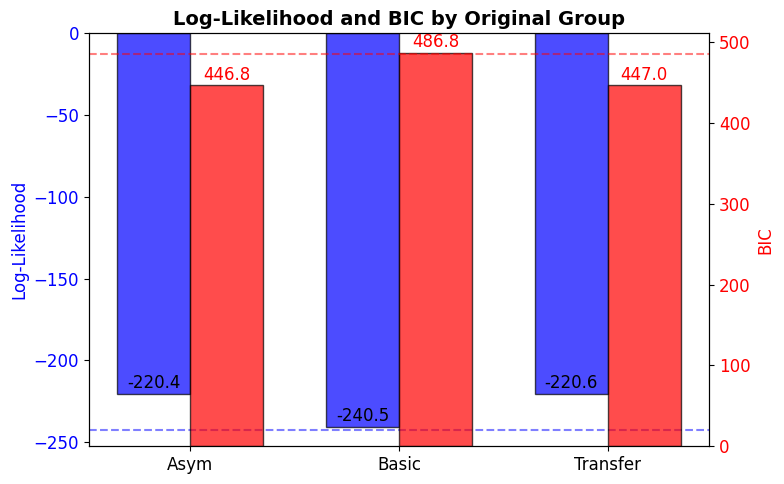

In [30]:
# BIC and log likelihoods comparison bar plot

# Defining group means
groups = ['Asym', 'Basic', 'Transfer']
ll_means = [group_means['asym'], group_means['basic'], group_means['transfer']]
bic_means = [group_means_bic['asym'], group_means_bic['basic'], group_means_bic['transfer']]

# Plotting raw values with dual axes
fig, ax1 = plt.subplots(figsize=(8,5))
x_pos = np.arange(len(groups))
width = 0.35

# Log-likelihood on left axis
color = 'blue'
bars1 = ax1.bar(x_pos - width/2, ll_means, width, label='Log-Likelihood', 
                color=color, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Log-Likelihood', color=color)
ax1.tick_params(axis='y', labelcolor=color)

# y-axis for BIC
ax2 = ax1.twinx()
color = 'red'
bars2 = ax2.bar(x_pos + width/2, bic_means, width, label='BIC', 
                color=color, alpha=0.7, edgecolor='black')
ax2.set_ylabel('BIC', color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Value labels
for i, (bar, val) in enumerate(zip(bars1, ll_means)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{val:.1f}', ha='center', va='bottom')

for i, (bar, val) in enumerate(zip(bars2, bic_means)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{val:.1f}', ha='center', va='bottom', color='red')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups)
ax1.set_title('Log-Likelihood and BIC by Original Group')

# Random baseline lines
ax1.axhline(y=-242.6, color='blue', linestyle='--', alpha=0.5, label='Chance (LL)')
ax2.axhline(y=485, color='red', linestyle='--', alpha=0.5, label='Null model (BIC)')

fig.tight_layout()
plt.show()

In [31]:
# H2: Can Bayesian model parameters predict original Q-learning group assignments?
# Using random forest

# Defining feature columns
feature_cols = ['best_temp', 'best_ll', 'bic', 'probability']

# Features preparation
features = results_df[['subject'] + feature_cols].copy().set_index('subject')

# Labels preparation
labels = highest_ll.set_index('subject')['group']

# Align (automatically matches on index)
features = features.loc[labels.index]

# Verifying sizes for alignment
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

# Cross-validated prediction
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(rf, features, labels, cv=cv)
print(f"Accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")
print(f"Chance level: {1/3:.3f}")

# Feature weight
rf.fit(features, labels)
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importance:")
print(importance)

Features shape: (58, 4)
Labels shape: (58,)
Accuracy: 0.497 (+/- 0.197)
Chance level: 0.333

Feature importance:
       feature  importance
0    best_temp    0.336500
2          bic    0.236070
3  probability    0.226336
1      best_ll    0.201094


In [32]:
# predictions using cross validation
cv_predictions = cross_val_predict(rf, features, labels, cv=cv)

# Confusion matrix using cross-validated predictions
cv_cm = confusion_matrix(labels, cv_predictions)
cv_cm_df = pd.DataFrame(cv_cm,
                        index=['Actual Transfer', 'Actual Basic', 'Actual Asym'],
                        columns=['Pred Transfer', 'Pred Basic', 'Pred Asym'])
print(cv_cm_df)

# Per-group accuracy
print("\n Per-group accuracy (Cross-validated)")
for i, group in enumerate(['Transfer', 'Basic', 'Asym']):
    correct = cv_cm[i, i]
    total = cv_cm[i, :].sum()
    print(f"{group}: {correct}/{total} = {correct/total*100:.1f}%")

# Comparison with original acc
print(f"Overall accuracy: {np.mean(cv_predictions == labels)*100:.1f}%")
print(f"Chance level: 33.3%")

                 Pred Transfer  Pred Basic  Pred Asym
Actual Transfer              1           7          8
Actual Basic                 6          23          2
Actual Asym                  3           3          5

 Per-group accuracy (Cross-validated)
Transfer: 1/16 = 6.2%
Basic: 23/31 = 74.2%
Asym: 5/11 = 45.5%
Overall accuracy: 50.0%
Chance level: 33.3%


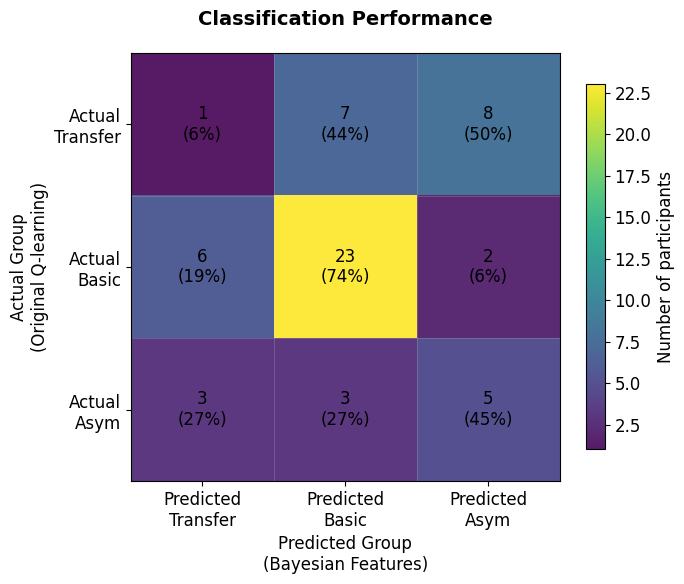

In [47]:
# CM visualization
# Getting predictions (using existing rf, features, labels, cv)
cv_predictions = cross_val_predict(rf, features, labels, cv=cv)
cm = confusion_matrix(labels, cv_predictions)

# Group names
group_names = ['Transfer', 'Basic', 'Asym']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='viridis', alpha=0.9)

cbar = ax.figure.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of participants')

ax.set_xticks(np.arange(len(group_names)))
ax.set_yticks(np.arange(len(group_names)))
ax.set_xticklabels(['Predicted\n' + g for g in group_names])
ax.set_yticklabels(['Actual\n' + g for g in group_names])

plt.setp(ax.get_xticklabels(), ha='center')

# Annotations
for i in range(len(group_names)):
    for j in range(len(group_names)):
        value = cm[i, j]
        percent = value / cm[i, :].sum() * 100
        text = f'{value}\n({percent:.0f}%)'
        
        ax.text(j, i, text, ha='center', va='center', color='black')

ax.set_ylabel('Actual Group\n(Original Q-learning)')
ax.set_xlabel('Predicted Group\n(Bayesian Features)')
ax.set_title('Classification Performance', pad=20)
ax.set_xticks(np.arange(-0.5, len(group_names), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(group_names), 1), minor=True)
ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.savefig('confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# Parameter recovery

In [35]:
model_ready_data.describe()

,trial_global,stimulus_idx,choice,reward
count,21870.000000,21870.000000,21870.000000,21870.000000
mean,178.170736,3.966347,0.453224,0.598994
std,103.097336,2.576474,0.497819,0.490113
min,1.000000,0.000000,0.000000,0.000000
25%,89.000000,2.000000,0.000000,0.000000
50%,178.000000,4.000000,0.000000,1.000000
75%,267.000000,6.000000,1.000000,1.000000
max,360.000000,8.000000,1.000000,1.000000


In [36]:
# Defining a function for simulating one fake participant with synthetic choice data where true temperature is known
def simulate_participant(true_temp, n_trials=350):
    np.random.seed(1)
    stimuli = np.random.randint(0, 9, n_trials)
    
    choices = []
    rewards = []
    
    alpha_beta = np.ones((9, 2, 2))
    
    for trial in range(n_trials):
        stim = stimuli[trial]
        
        ev_attract = alpha_beta[stim][0][0] / (alpha_beta[stim][0][0] + alpha_beta[stim][0][1])
        ev_not = alpha_beta[stim][1][0] / (alpha_beta[stim][1][0] + alpha_beta[stim][1][1])
        
        p_attract = np.exp(ev_attract * true_temp) / (np.exp(ev_attract * true_temp) + np.exp(ev_not * true_temp))
        action = 0 if np.random.random() < p_attract else 1
        
# Reward probability 0.6 for chosen action was chosen to make fake participants more realistic, 
# as the mean reward from model_ready_data.describe() table above is 0.598994, rounded to 60.
        reward_prob = 0.6
        reward = 1 if np.random.random() < reward_prob else 0
        
        choices.append(action)
        rewards.append(reward)
        
        if reward == 1:
            alpha_beta[stim][action][0] += 1
        else:
            alpha_beta[stim][action][1] += 1
    
    sim_data = pd.DataFrame({
        'stimulus_idx': stimuli,
        'choice': choices,
        'reward': rewards
    })
        
    return sim_data

In [37]:
# Recovery function, which takes fake participant data (sim_data) and tries to find what temperature best fits it
def recover_temperature(sim_data):    
    def neg_log_likelihood(temp):
        return -calculate_log_likelihood(sim_data, temp[0]) 

    result = minimize(neg_log_likelihood, x0=[1.0], bounds=[(0.1, 20)]) # finds temp that best fits fake data
    return result.x[0] # recovered temperature

In [38]:
# Running recovery on multiple simulations
true_temps = [0.5, 1.0, 2.0, 5.0]
recovered = []

for true_temp in true_temps:
    for sim in range(10):
        sim_data = simulate_participant(true_temp)
        rec_temp = recover_temperature(sim_data)
        recovered.append({'true': true_temp, 'recovered': rec_temp})

# Simulating 10 fake participants for each temperature value [0.5, 1.0, 2.0, 5.0].
# Storing both true and recovered values for comparison

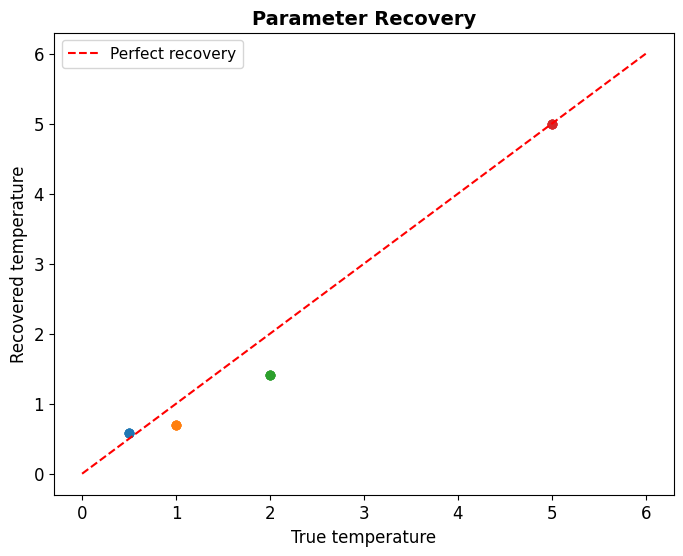

In [39]:
# Parameter recovery plot
results_df = pd.DataFrame(recovered)

plt.figure(figsize=(8, 6))
for temp in true_temps:
    subset = results_df[results_df['true'] == temp]
    plt.scatter([temp]*len(subset), subset['recovered'], alpha=0.5)

plt.plot([0, 6], [0, 6], 'r--', label='Perfect recovery')
plt.xlabel('True temperature')
plt.ylabel('Recovered temperature')
plt.legend()
plt.title('Parameter Recovery')
plt.show()

In [40]:
# Calculating correlation
correlation = results_df['true'].corr(results_df['recovered'])
print(f"Correlation: {correlation:.3f}")

Correlation: 0.990


In [41]:
# r=0.99, the model shows excellent recovery of the true temperature, true and recovered temperatures match almost exactly

In [42]:
# Calculating improvement of each participant's accuracy over time

# Each participant's data is stored separately in a list, accounting for different cumulative trial lengths:
trial_accuracies = []

for participant in all_subjects:
    pdata = model_ready_data[model_ready_data['subject'] == participant].sort_values('trial_global')

    cumlative_correct = 0 # Total correct
    trial_acc = [] # storing accuracy after each trial
    
    for i, (_, trial) in enumerate(pdata.iterrows()):
        # If trial rewarded, increase correct count
        if trial['reward'] == 1:
            cumlative_correct += 1
        trial_acc.append(cumlative_correct / (i + 1)) # Calculating accuracy up to x trial
    
    trial_accuracies.append(trial_acc) # storing participants learning curve


acc_df = pd.DataFrame(trial_accuracies).T  # Transpose so trials are rows, participants are columns

mean_acc = acc_df.mean(axis=1, skipna=True)
sem_acc = acc_df.sem(axis=1, skipna=True)

n_participants_per_trial = acc_df.notna().sum(axis=1)
cutoff = int(len(all_subjects) * 0.8)  # 80% cutoff used
valid_trials = n_participants_per_trial >= cutoff
trials = np.arange(1, len(mean_acc) + 1)

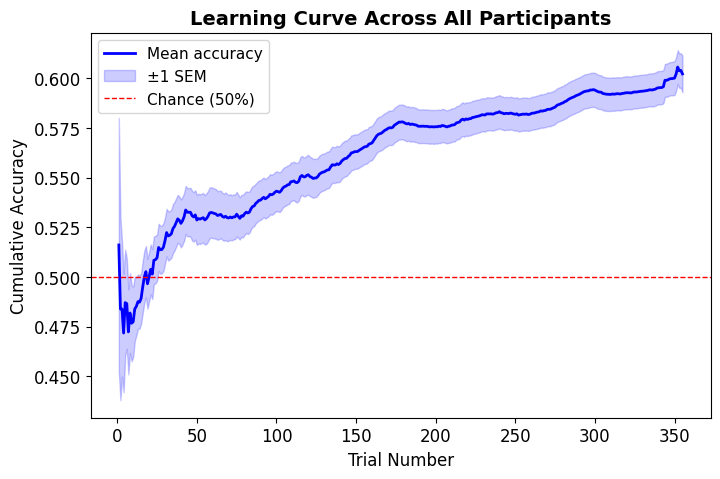

In [43]:
# Plotting cumulative learning
plt.figure(figsize=(8, 5))
plt.plot(trials[valid_trials], mean_acc[valid_trials], 'b-', linewidth=2, label='Mean accuracy')
plt.fill_between(trials[valid_trials], 
                 mean_acc[valid_trials] - sem_acc[valid_trials], 
                 mean_acc[valid_trials] + sem_acc[valid_trials], 
                 alpha=0.2, color='b', label='±1 SEM')

plt.axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Chance (50%)')

plt.xlabel('Trial Number')
plt.ylabel('Cumulative Accuracy')
plt.title('Learning Curve Across All Participants')
plt.legend()
plt.show()